In [1]:
# Libraries used for data simulation
import math as m
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
drivers=pd.read_excel('drivers.xlsx')
riders=pd.read_excel('riders.xlsx')

In [7]:
# drivers data info
drivers.info()
drivers.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4719 entries, 0 to 4718
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                4719 non-null   int64         
 1   arrival_time      4719 non-null   float64       
 2   offline_time      4719 non-null   float64       
 3   initial_location  4719 non-null   object        
 4   current_location  4719 non-null   object        
 5   status            4719 non-null   object        
 6   arrival_datetime  4719 non-null   datetime64[ns]
 7   offline_datetime  4719 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(1), object(3)
memory usage: 295.1+ KB


,id,arrival_time,offline_time,initial_location,current_location,status,arrival_datetime,offline_datetime
0,1,5.011975,11.638223,"(0.7897740952818868, 8.194226996886005)","(13.492895938215721, 17.375090044074234)",offline,2025-12-01 13:00:43.110,2025-12-01 19:38:17.601
1,2,5.557763,11.732854,"(4.600342938200451, 13.82151625336585)","(13.6809497478333, 15.070060581064372)",offline-scheduled,2025-12-01 13:33:27.947,2025-12-01 19:43:58.273
2,3,5.661047,12.723458,"(9.09829206926925, 11.669336718393772)","(15.86922281798255, 9.936190354974855)",offline-scheduled,2025-12-01 13:39:39.768,2025-12-01 20:43:24.450
3,4,5.757413,12.793147,"(14.723720219958555, 14.743429470057318)","(14.232702333916698, 12.939560071816741)",offline-scheduled,2025-12-01 13:45:26.686,2025-12-01 20:47:35.330
4,5,5.769205,12.431118,"(13.023825947458846, 12.501871643860605)","(19.845683334071563, 7.3885004325174215)",offline-scheduled,2025-12-01 13:46:09.139,2025-12-01 20:25:52.025


In [9]:
# riders info 
riders.info()
riders.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34421 entries, 0 to 34420
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                34421 non-null  int64         
 1   request_time      34421 non-null  float64       
 2   pickup_time       34421 non-null  float64       
 3   dropoff_time      34421 non-null  float64       
 4   pickup_location   34421 non-null  object        
 5   dropoff_location  34421 non-null  object        
 6   status            34421 non-null  object        
 7   request_datetime  34421 non-null  datetime64[ns]
 8   pickup_datetime   34142 non-null  datetime64[ns]
 9   dropoff_datetime  34134 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(3), int64(1), object(3)
memory usage: 2.6+ MB


,id,request_time,pickup_time,dropoff_time,pickup_location,dropoff_location,status,request_datetime,pickup_datetime,dropoff_datetime
0,1,5.048803,5.372603,5.668817,"(8.52776815255513, 11.374422951736026)","(11.22406718305943, 18.28586415472845)",dropped-off,2025-12-01 13:02:55.690,2025-12-01 13:22:21.370,2025-12-01 13:40:07.743
1,2,5.113495,5.344117,5.658663,"(4.7260253234018075, 13.921168220313202)","(11.219433016467919, 9.224932723238288)",dropped-off,2025-12-01 13:06:48.580,2025-12-01 13:20:38.822,2025-12-01 13:39:31.187
2,3,5.114319,5.819045,6.154474,"(9.34931432850313, 14.855954034601385)","(15.818906976292498, 14.556629597532137)",dropped-off,2025-12-01 13:06:51.547,2025-12-01 13:49:08.563,2025-12-01 14:09:16.107
3,4,5.210384,5.492225,5.915581,"(5.341657715440439, 9.121586876730834)","(11.832789025965816, 11.90864135355879)",dropped-off,2025-12-01 13:12:37.383,2025-12-01 13:29:32.010,2025-12-01 13:54:56.092
4,5,5.229512,5.421566,6.019653,"(5.444067188695589, 13.774420071355813)","(11.208517457838962, 5.792638826367501)",dropped-off,2025-12-01 13:13:46.244,2025-12-01 13:25:17.639,2025-12-01 14:01:10.751


In [24]:
riders[riders['status']=='abandoned']

8      NaT
11     NaT
16     NaT
20     NaT
21     NaT
        ..
3855   NaT
3878   NaT
3958   NaT
4862   NaT
4865   NaT
Name: pickup_datetime, Length: 100, dtype: datetime64[ns]

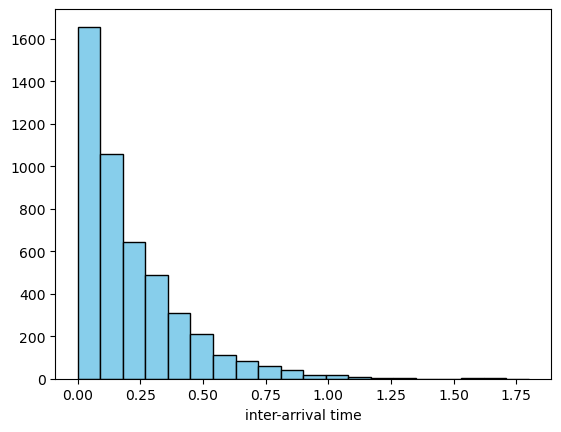

In [93]:
# driver interarrival from data 
drivers_interarrival = drivers["arrival_time"].diff().dropna().values
drivers_interarrival
plt.hist(drivers_interarrival,bins=20,color="skyblue", edgecolor="black")
plt.xlabel('inter-arrival time')
plt.show()

In [79]:
# lambda calculation from maximum likelihood estimation for interararival time
drivers_interarrival_mean=drivers_interarrival = drivers["arrival_time"].diff().dropna().mean()
#n=len(drivers_interarrival)-1
lambda_dri=1/drivers_interarrival_mean
print(f'lambda for driver interarriavl  from data : {lambda_dri}')

lambda for driver interarriavl  from data : 4.7422539616801105


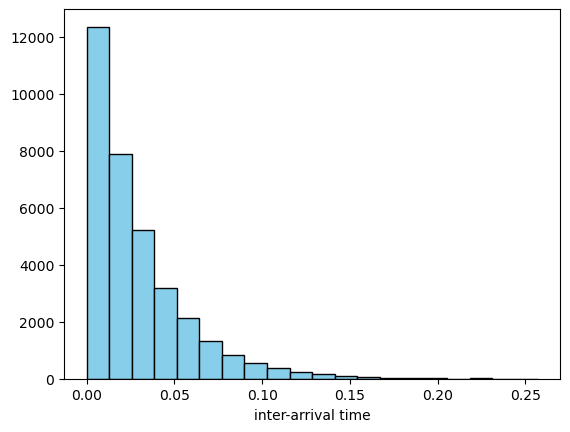

In [94]:
# rider interarrival from data 
riders_interarrival = riders["request_time"].diff().dropna().values
riders_interarrival
plt.hist(riders_interarrival,bins=20,color="skyblue", edgecolor="black")
plt.xlabel('inter-arrival time')
plt.show()

In [83]:
# lambda calculation from maximum likelihood estimation for interararival time
riders_interarrival_mean=riders_interarrival = riders["request_time"].diff().dropna().mean()
#n=len(drivers_interarrival)-1
lambda_rid=1/riders_interarrival_mean
print(f'lambda for driver interarriavl  from data : {lambda_rid}')

lambda for driver interarriavl  from data : 34.596111136023964


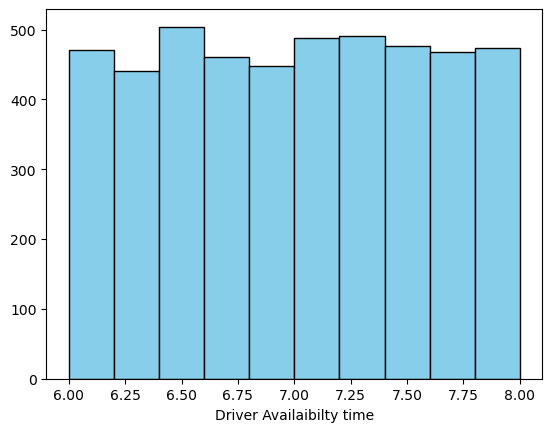

In [95]:
# driver availiability
driver_avail=(drivers.offline_time-drivers.arrival_time).values
plt.hist(driver_avail,bins=10,color="skyblue", edgecolor="black")
plt.xlabel('Driver Availaibilty time')
plt.show()